In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from nilearn import plotting
import pandas as pd
%matplotlib inline
import matplotlib.image as mpimg
import networkx as nx
import h5py as h5
import torch
from paper.helper_functions_paper import *

In [21]:
#schaefer 116 coordinates
subcortical_coords = np.loadtxt('paper/data/external/Tian_Subcortex_S1_3T_COG.txt')
Schaefer100 = pd.read_csv('paper/data/external/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_2mm.Centroid_RAS.csv')
cortical_coords = np.array(Schaefer100[['R','A','S']])
SchaeferTian116_coords = np.concatenate((np.array(subcortical_coords),cortical_coords),axis=0)

networks_names = ['Subcortical','Visual','Somatomotor','Dorsal attention','Salience ventral attention','Limbic','Control','Default mode']
networks_colors = ['black','red','blue','green','purple','orange','brown','pink']
networks_order = [0,1,2,3,4,5,6,7,1,2,3,4,5,6,7]
networks_number_of_rois_hemisphere = [16,9,6,8,7,3,4,13,
                           8,8,7,5,2,9,11]
networks_number_of_rois2 = [16,17,14,15,12,5,13,24]

network_indices = [] # indicates indices from the Schaefer 116 atlas into a label where networks are put together
network_indices2 = [] #indicates the indices in each network after relabeling
network_indices3 = [] #indicates the yeo network each area belongs to

start1 = 0
start2 = 66
start3 = 0
#reorder such that the first left and right hemisphere are ordered together
for network in range(8):
    if network==0:
        tmp = np.concatenate((np.arange(start1,start1+networks_number_of_rois_hemisphere[network],step=2),
                                np.arange(start1+1,start1+networks_number_of_rois_hemisphere[network],step=2)))
        network_indices.append(tmp)
        start1 += networks_number_of_rois_hemisphere[network]
    else:
        network_index = np.where(np.array(networks_order)==network)[0]
        tmp = np.concatenate((np.arange(start1,start1+networks_number_of_rois_hemisphere[network_index[0]]),
                             np.arange(start2,start2+networks_number_of_rois_hemisphere[network_index[1]])))
        network_indices.append(tmp)
        start1 += networks_number_of_rois_hemisphere[network_index[0]]
        start2 += networks_number_of_rois_hemisphere[network_index[1]]
    network_indices2.append(np.arange(start3,start3+networks_number_of_rois2[network]))
    network_indices3.append(np.ones(networks_number_of_rois2[network])*network)
    start3 += networks_number_of_rois2[network]
network_indices_concat = np.concatenate(network_indices)
network_indices3 = np.concatenate(network_indices3).astype(int)

In [22]:
angles = np.array([0, 0.25, 0.5, 0.75, 1.0])  # Normalized positions of -pi to pi
colors = ['blue', 'green', 'red', 'yellow', 'blue']  # Color for each angle

# Create a custom colormap
cyclic_cmap = LinearSegmentedColormap.from_list('cyclic_map', list(zip(angles, colors)))

# make another colormap that is the second half of 'bwr'
bwr2 = plt.cm.bwr
colors_bwr2 = bwr2(np.linspace(0, 1, 256))
colors_bwr2 = colors_bwr2[128:]
cmap_bwr2 = LinearSegmentedColormap.from_list('bwr2', colors_bwr2)

In [23]:
def plot_matrix(matrix, title, cmap='bwr',clim=(-0.5,0.5),show_boxes=True):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 8), gridspec_kw={'height_ratios': [10, 1], 'width_ratios': [1,10], 'wspace':-0.05, 'hspace':-0.15})
    plotting.plot_matrix(matrix, cmap=cmap, colorbar=False, axes=ax[0,1],vmin=clim[0],vmax=clim[1])
    ax[0,1].set_xticks([])
    ax[0,1].set_yticks([])
    ax[1,0].axis('off')
    ax[1,1].axis('off')
    ax[0,0].axis('off')
    
    if show_boxes:
        # Create a 1D array that represents the colored boxes
        color_boxes = np.zeros((1, matrix.shape[0], 3))

        # Assign colors to the corresponding segments
        for i, color in enumerate(networks_colors):
            start = sum(networks_number_of_rois2[:i])
            end = start + networks_number_of_rois2[i]
            #use the predefined colors
            color_boxes[0, start:end, :] = plt.cm.colors.to_rgb(color)
            
        # Plot the color boxes below the matrix
        ax[0,0].imshow(np.swapaxes(color_boxes,0,1), aspect='auto')
        new_ax00_position = [ax[0,0].get_position().x0, ax[0,1].get_position().y0, ax[0,0].get_position().width*0.5, ax[0,1].get_position().height]
        ax[0,0].set_position(new_ax00_position)
        ax[1,1].imshow(color_boxes, aspect='auto')
        new_ax11_position = [ax[1,1].get_position().x0, ax[1,1].get_position().y0-0.025, ax[0,1].get_position().width, ax[1,1].get_position().height*0.5]
        ax[1,1].set_position(new_ax11_position)
    fig.savefig('paper/experiments_realdata/figures_tmp/'+title+'.png',dpi=300,bbox_inches='tight')
    plt.close()
    return

def avg_matrix_in_networks(matrix, network_indices, do_significance=False):
    avg_matrix = np.zeros((len(network_indices), len(network_indices)),dtype=matrix.dtype)
    for i, network1 in enumerate(network_indices):
        for j, network2 in enumerate(network_indices):
            if j<i:
                continue
            avg_matrix[i, j] = np.mean(matrix[network1, :][:, network2])
    avg_matrix = avg_matrix + avg_matrix.T - np.diag(np.diag(avg_matrix))

    if not do_significance:
        return avg_matrix, None
    
    # now do 1000 permutations to get significance
    significance_matrix = np.zeros((len(network_indices), len(network_indices)))
    num_permutations = 1000
    for t in range(num_permutations):
        permuted_indices = np.random.permutation(matrix.shape[0])
        permuted_matrix = matrix[permuted_indices, :][:, permuted_indices]
        for i, network1 in enumerate(network_indices):
            for j, network2 in enumerate(network_indices):
                permuted_avg = np.mean(permuted_matrix[network1, :][:, network2])
                if np.abs(permuted_avg) >= np.abs(avg_matrix[i, j]):
                    significance_matrix[i, j] += 1
    significance_matrix = significance_matrix / num_permutations
    return avg_matrix, significance_matrix

def get_Z(params,idx,sort=True,model='Watson'):
    if model in ['Watson','Complex_Watson']:
        Z = np.outer(params['mu'][:,idx],params['mu'][:,idx].conj())*np.sqrt(params['kappa'][idx])
    elif model in ['ACG','Complex_ACG','MACG']:
        M = params['M'][idx]
        o = np.linalg.norm(M,'fro')**2
        gamma = 1/(1+o/116)
        Z = gamma*(M@M.conj().T+np.eye(116))
    elif model in ['SingularWishart', 'Normal', 'Complex_Normal']:
        M = params['M'][idx]
        gamma = params['gamma'][idx]
        Z = M@M.T.conj()+gamma*np.eye(116)
    else:
        raise ValueError('Model not recognized')
    if sort:
        Z = Z[network_indices_concat,:][:,network_indices_concat]
    return Z

## Global coherence network

In [24]:
# global phase coherence without GSR
data_file = 'paper/data/processed/concatenated_datasets/REST1REST2fMRI_SchaeferTian116.h5'
num_subs = 10
with h5.File(data_file,'r') as f:
    data_train = f['U_complex_train'][:][:1200*num_subs]
Z_global = np.mean(data_train@np.swapaxes(data_train.conj(),-2,-1),axis=0)
Z_global = Z_global[network_indices_concat,:][:,network_indices_concat]

c = 0.005
plot_matrix(np.real(Z_global), 'Global phase coupling, real',clim=(-c,c))
plot_matrix(np.imag(Z_global), 'Global phase coupling, imaginary',clim=(-c,c))
plot_matrix(np.abs(Z_global), 'Global phase coupling, magnitude',clim=(0,c),cmap=cmap_bwr2)
plot_matrix(np.angle(Z_global), 'Global phase coupling, angle',clim=(-np.pi,np.pi),cmap=cyclic_cmap)

In [25]:
# global phase coherence with GSR
data_file = 'paper/data/processed/concatenated_datasets/REST1REST2fMRI_SchaeferTian116_GSR.h5'
num_subs = 10
with h5.File(data_file,'r') as f:
    data_train = f['U_complex_train'][:][:1200*num_subs]
Z_global_GSR = np.mean(data_train@np.swapaxes(data_train.conj(),-2,-1),axis=0)
Z_global_GSR = Z_global_GSR[network_indices_concat,:][:,network_indices_concat]

c = 0.005
plot_matrix(np.real(Z_global_GSR), 'Global phase coupling, GSR, real',clim=(-c,c))
plot_matrix(np.imag(Z_global_GSR), 'Global phase coupling, GSR, imaginary',clim=(-c,c))
plot_matrix(np.abs(Z_global_GSR), 'Global phase coupling, GSR, magnitude',clim=(0,c),cmap=cmap_bwr2)
plot_matrix(np.angle(Z_global_GSR), 'Global phase coupling, GSR, angle',clim=(-np.pi,np.pi),cmap=cyclic_cmap)

In [26]:
# global phase amplitude coupling with GSR
data_file = 'paper/data/processed/concatenated_datasets/REST1REST2fMRI_SchaeferTian116_GSR.h5'
num_subs = 10
with h5.File(data_file,'r') as f:
    phase_train = f['U_complex_train'][:][:1200*num_subs]
    magn_train = f['A_train'][:][:1200*num_subs][:,:,None]
    data_train = phase_train*magn_train
Z_global_GSR = np.mean(data_train@np.swapaxes(data_train.conj(),-2,-1),axis=0)
Z_global_GSR = Z_global_GSR[network_indices_concat,:][:,network_indices_concat]

c = 2.5
plot_matrix(np.abs(Z_global_GSR), 'Global phase-amplitude coupling, GSR, magnitude',clim=(0,c),cmap=cmap_bwr2)
plot_matrix(np.angle(Z_global_GSR), 'Global phase-amplitude coupling, GSR, angle',clim=(-np.pi,np.pi),cmap=cyclic_cmap)

In [27]:
# global amplitude coupling with GSR
data_file = 'paper/data/processed/concatenated_datasets/REST1REST2fMRI_SchaeferTian116_GSR.h5'
num_subs = 10
with h5.File(data_file,'r') as f:
    data_train = f['timeseries_train'][:][:1200*num_subs]
Z_global_GSR = np.mean(data_train@np.swapaxes(data_train.conj(),-2,-1),axis=0)
Z_global_GSR = Z_global_GSR[network_indices_concat,:][:,network_indices_concat]

c = 250
plot_matrix(Z_global_GSR, 'Global amplitude coupling, GSR',clim=(-c,c))

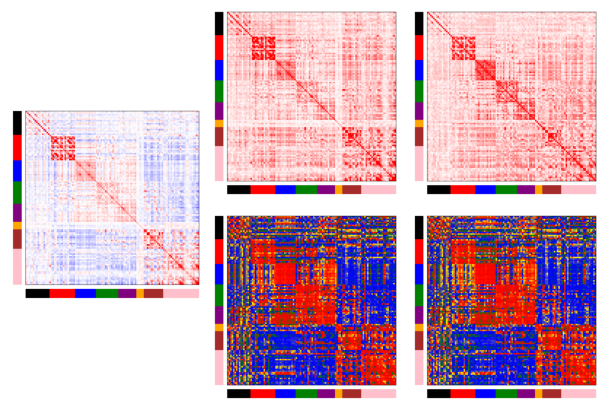

In [28]:
# amplitude vs phase-amplitude vs pahse

fig = plt.figure(figsize=(6,4),constrained_layout=True)
gs = fig.add_gridspec(2,3,width_ratios=[1,1,1],height_ratios=[1,1],hspace=0)
ax00 = fig.add_subplot(gs[:,0])
ax00.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global amplitude coupling, GSR.png'))
ax00.axis('off')

ax01 = fig.add_subplot(gs[0,1])
ax01.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase-amplitude coupling, GSR, magnitude.png'))
ax01.axis('off')

ax02 = fig.add_subplot(gs[1,1])
ax02.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase-amplitude coupling, GSR, angle.png'))
ax02.axis('off')

ax10 = fig.add_subplot(gs[0,2])
ax10.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, GSR, magnitude.png'))
ax10.axis('off')

ax11 = fig.add_subplot(gs[1,2])
ax11.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, GSR, angle.png'))
ax11.axis('off')

fig.savefig('paper/experiments_realdata/figures/Global_coupling.png',dpi=200,bbox_inches='tight')

## K1 solutions

In [29]:
# # #K1 Watson
clim = (-0.5,0.5)
clim2 = (0,0.5)

#K1 complex ACG rank 1
params = np.load('paper/data/results/116_results/params/Complex_ACG_rank1_K1_params.npy', allow_pickle=True).item()
Z = get_Z(params,idx=0,model='Complex_ACG')
plot_matrix(np.real(Z), 'Complex ACG rank 1 K=1, real',clim=clim)
plot_matrix(np.imag(Z), 'Complex ACG rank 1 K=1, imaginary',clim=clim)
plot_matrix(np.abs(Z), 'Complex ACG rank 1 K=1, magnitude',clim=clim2,cmap=cmap_bwr2)
plot_matrix(np.angle(Z), 'Complex ACG rank 1 K=1, angle',clim=(-np.pi,np.pi),cmap=cyclic_cmap)

#K1 complex ACG rank 10
print('Complex ACG rank 10')
params = np.load('paper/data/results/116_results/params/Complex_ACG_rank10_K1_params.npy', allow_pickle=True).item()
Z = get_Z(params,idx=0,model='Complex_ACG')
plot_matrix(np.real(Z), 'Complex ACG rank 10, real',clim=clim)
plot_matrix(np.imag(Z), 'Complex ACG rank 10, imaginary',clim=clim)
plot_matrix(np.abs(Z), 'Complex ACG rank 10, magnitude',clim=clim2,cmap=cmap_bwr2)
plot_matrix(np.angle(Z), 'Complex ACG rank 10, angle',clim=(-np.pi,np.pi),cmap=cyclic_cmap)

#K1 complex ACG rank 25
print('Complex ACG rank 25')
params = np.load('paper/data/results/116_results/params/Complex_ACG_rank25_K1_params.npy', allow_pickle=True).item()
Z = get_Z(params,idx=0,model='Complex_ACG')
plot_matrix(np.real(Z), 'Complex ACG rank 25, real',clim=clim)
plot_matrix(np.imag(Z), 'Complex ACG rank 25, imaginary',clim=clim)
plot_matrix(np.abs(Z), 'Complex ACG rank 25, magnitude',clim=clim2,cmap=cmap_bwr2)
plot_matrix(np.angle(Z), 'Complex ACG rank 25, angle',clim=(-np.pi,np.pi),cmap=cyclic_cmap)

#K1 complex ACG rank 100
print('Complex ACG rank 100')
params = np.load('paper/data/results/116_results/params/Complex_ACG_rank100_K1_params.npy', allow_pickle=True).item()
Z = get_Z(params,idx=0,model='Complex_ACG')
plot_matrix(np.real(Z), 'Complex ACG rank 100, real',clim=clim)
plot_matrix(np.imag(Z), 'Complex ACG rank 100, imaginary',clim=clim)
plot_matrix(np.abs(Z), 'Complex ACG rank 100, magnitude',clim=clim2,cmap=cmap_bwr2)
plot_matrix(np.angle(Z), 'Complex ACG rank 100, angle',clim=(-np.pi,np.pi),cmap=cyclic_cmap)

FileNotFoundError: [Errno 2] No such file or directory: 'paper/data/results/116_results/params/Complex_ACG_rank1_K1_params.npy'

## main paper fig

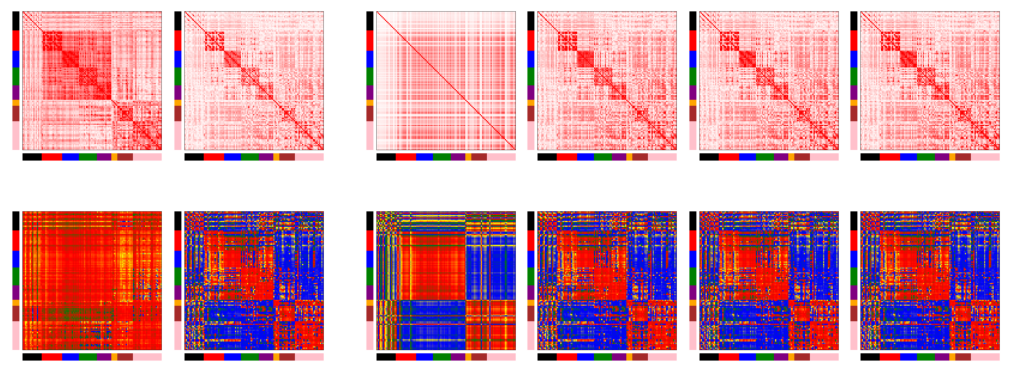

In [ ]:
fig = plt.figure(figsize=(10,4),constrained_layout=True)
gs = fig.add_gridspec(2,7,width_ratios=[1,1,0.2,1,1,1,1],hspace=0)

ax00 = fig.add_subplot(gs[0,0])
ax00.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, magnitude.png'))
ax00.axis('off')
ax10 = fig.add_subplot(gs[1,0])
ax10.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, angle.png'))
ax10.axis('off')

ax01 = fig.add_subplot(gs[0,1])
ax01.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, GSR, magnitude.png'))
ax01.axis('off')
ax11 = fig.add_subplot(gs[1,1])
ax11.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, GSR, angle.png'))
ax11.axis('off')

ax30 = fig.add_subplot(gs[0,3])
ax30.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 1 K=1, magnitude.png'))
ax30.axis('off')
ax31 = fig.add_subplot(gs[1,3])
ax31.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 1 K=1, angle.png'))
ax31.axis('off')

ax40 = fig.add_subplot(gs[0,4])
ax40.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 10, magnitude.png'))
ax40.axis('off')
ax41 = fig.add_subplot(gs[1,4])
ax41.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 10, angle.png'))
ax41.axis('off')

ax50 = fig.add_subplot(gs[0,5])
ax50.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 25, magnitude.png'))
ax50.axis('off')
ax51 = fig.add_subplot(gs[1,5]) 
ax51.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 25, angle.png'))
ax51.axis('off')

ax60 = fig.add_subplot(gs[0,6])
ax60.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 100, magnitude.png'))
ax60.axis('off')
ax61 = fig.add_subplot(gs[1,6])
ax61.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 100, angle.png'))
ax61.axis('off')

fig.savefig('paper/experiments_realdata/figures/Global_phase_coherence.png',dpi=300,bbox_inches='tight')

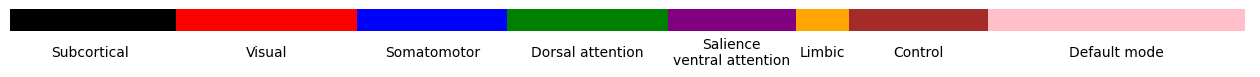

In [ ]:
#let the first subplot show the 8 colored boxes vertically with the network names next to them
networks_names2 = ['Subcortical','Visual','Somatomotor','Dorsal attention','Salience\nventral attention','Limbic','Control','Default mode']
fig,ax = plt.subplots(1,1,figsize=(16,1))
color_boxes = np.zeros((116, 2, 3))
for i, color in enumerate(networks_colors):
    start = sum(networks_number_of_rois2[:i])
    end = start + networks_number_of_rois2[i]
    color_boxes[start:end,:, :] = plt.cm.colors.to_rgb(color)
ax.imshow(np.swapaxes(color_boxes,0,1), aspect='equal')
ax.set_xlim(0,116)
ax.axis('off')
for i in range(8):
    ax.text((sum(networks_number_of_rois2[:i])+networks_number_of_rois2[i]/2-0.5),3.5, networks_names2[i], ha='center', va='center',fontsize=10)
fig.savefig('paper/experiments_realdata/figures/Networks_labels.png',dpi=300,bbox_inches='tight')

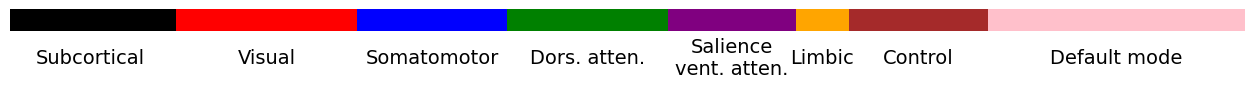

In [ ]:
#let the first subplot show the 8 colored boxes vertically with the network names next to them
networks_names2 = ['Subcortical','Visual','Somatomotor','Dors. atten.','Salience\nvent. atten.','Limbic','Control','Default mode']
fig,ax = plt.subplots(1,1,figsize=(16,1))
color_boxes = np.zeros((116, 2, 3))
for i, color in enumerate(networks_colors):
    start = sum(networks_number_of_rois2[:i])
    end = start + networks_number_of_rois2[i]
    color_boxes[start:end,:, :] = plt.cm.colors.to_rgb(color)
ax.imshow(np.swapaxes(color_boxes,0,1), aspect='equal')
ax.set_xlim(0,116)
ax.axis('off')
for i in range(8):
    ax.text((sum(networks_number_of_rois2[:i])+networks_number_of_rois2[i]/2-0.5),4, networks_names2[i], ha='center', va='center',fontsize=14)
fig.savefig('paper/experiments_realdata/figures/Networks_labels.pdf',bbox_inches='tight')

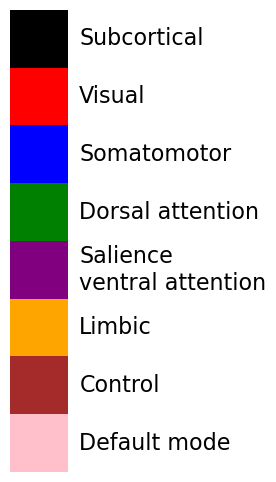

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(2,6))

# Each network gets an equal-size block: 8 × 20 pixels
color_boxes = np.zeros((8, 1, 3))

for i, color in enumerate(networks_colors):
    # equal-size segments: one block per network
    start = i
    end = i + 1
    color_boxes[start:end, :, :] = plt.cm.colors.to_rgb(color)

# Show vertically
ax.imshow(color_boxes, aspect='equal')
ax.axis('off')

# Add labels to the right of each block
for i in range(8):
    ax.text(0.7, i, networks_names2[i],
            ha='left', va='center', fontsize=16)
fig.savefig('paper/experiments_realdata/figures/Networks_labels_vertical.png',dpi=300,bbox_inches='tight')

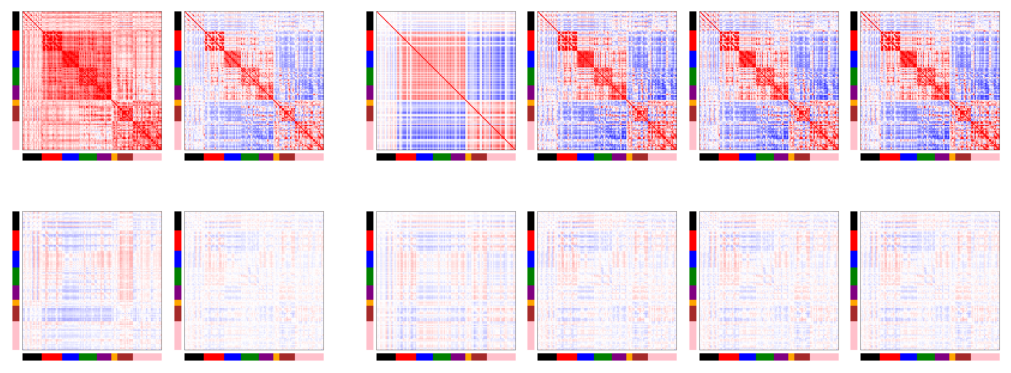

In [ ]:
fig = plt.figure(figsize=(10,4),constrained_layout=True)
gs = fig.add_gridspec(2,7,width_ratios=[1,1,0.2,1,1,1,1],hspace=0)

ax00 = fig.add_subplot(gs[0,0])
ax00.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, real.png'))
ax00.axis('off')
ax10 = fig.add_subplot(gs[1,0])
ax10.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, imaginary.png'))
ax10.axis('off')

ax01 = fig.add_subplot(gs[0,1])
ax01.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, GSR, real.png'))
ax01.axis('off')
ax11 = fig.add_subplot(gs[1,1])
ax11.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Global phase coupling, GSR, imaginary.png'))
ax11.axis('off')

ax30 = fig.add_subplot(gs[0,3])
ax30.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 1 K=1, real.png'))
ax30.axis('off')
ax31 = fig.add_subplot(gs[1,3])
ax31.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 1 K=1, imaginary.png'))
ax31.axis('off')

ax40 = fig.add_subplot(gs[0,4])
ax40.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 10, real.png'))
ax40.axis('off')
ax41 = fig.add_subplot(gs[1,4])
ax41.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 10, imaginary.png'))
ax41.axis('off')

ax50 = fig.add_subplot(gs[0,5])
ax50.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 25, real.png'))
ax50.axis('off')
ax51 = fig.add_subplot(gs[1,5]) 
ax51.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 25, imaginary.png'))
ax51.axis('off')

ax60 = fig.add_subplot(gs[0,6])
ax60.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 100, real.png'))
ax60.axis('off')
ax61 = fig.add_subplot(gs[1,6])
ax61.imshow(mpimg.imread('paper/experiments_realdata/figures_tmp/Complex ACG rank 100, imaginary.png'))
ax61.axis('off')

fig.savefig('paper/experiments_realdata/figures/Global_phase_coherence_realimag.png',dpi=300,bbox_inches='tight')